# 2. EDA — Who and What Is Represented?

Before selecting a problem, we need a shared picture of the dataset. This
stage answers four basic questions:

1. How many customers, usage records, and tickets are available?
2. How are customers distributed across all subscription plans?
3. Does the existing technical-priority queue differ by plan?
4. How much satisfaction evidence is actually available, and how are the
   recorded ratings distributed?

This is descriptive EDA. It shows who is represented and how the current
queue is composed; it does not show revenue, service quality, or causal
effects.

In [1]:
from common import (
    clean_source, save_show, ARTIFACTS,
    BLUE, TEAL, AMBER, PURPLE, RED, GREY, LIGHT_GREY,
    PLAN_ORDER, PLAN_COLORS, PRIORITY_ORDER, PRIORITY_COLORS,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

customers = pd.read_parquet(ARTIFACTS / "customers.parquet")
tickets = pd.read_parquet(ARTIFACTS / "tickets.parquet")
usage = pd.read_parquet(ARTIFACTS / "usage.parquet")
print(f"Loaded {len(customers):,} customers, {len(tickets):,} tickets, {len(usage):,} usage rows.")

Loaded 8,320 customers, 8,469 tickets, 42,210 usage rows.


## 2.1 Data Overview and Plan Mix

The left panel below describes the **customer population**. The right
panel describes the **ticket queue** — so a customer with several tickets
appears several times there. Keeping these separate matters: population
share and queue share answer different questions.

In [2]:
data_overview = pd.DataFrame({
    "source": ["Customers", "Product usage", "Support tickets"],
    "row grain": ["One customer", "One customer-product-month", "One support ticket"],
    "rows": [len(customers), len(usage), len(tickets)],
})
display(data_overview.style.hide(axis="index").format({"rows": "{:,}"}))

plan_summary = customers["plan_type"].value_counts().reindex(PLAN_ORDER, fill_value=0).rename("customers").to_frame()
plan_summary["share"] = plan_summary["customers"] / len(customers)
non_free_count = int(customers["plan_type"].ne("Free").sum())
free_count = int(customers["plan_type"].eq("Free").sum())

display(Markdown("**Customer plan mix**"))
display(plan_summary.style.format({"customers": "{:,}", "share": "{:.1%}"}))

source,row grain,rows
Customers,One customer,"8,320"
Product usage,One customer-product-month,"42,210"
Support tickets,One support ticket,"8,469"


**Customer plan mix**

,customers,share
plan_type,,
Free,"1,472",17.7%
Standard,"3,309",39.8%
Premium,"2,337",28.1%
Enterprise,"1,202",14.4%


## 2.2 Does Technical Priority Already Differ by Plan?

Join plan to tickets through the unique customer email, then look at the
percentage of Low/Medium/High/Critical tickets within each plan.

In [3]:
baseline_ticket_view = tickets.merge(
    customers[["customer_email", "plan_type"]],
    on="customer_email", how="left", validate="many_to_one",
)
assert len(baseline_ticket_view) == len(tickets)
priority_by_plan_count = pd.crosstab(
    baseline_ticket_view["plan_type"], baseline_ticket_view["ticket_priority"]
).reindex(index=PLAN_ORDER, columns=PRIORITY_ORDER, fill_value=0)
priority_by_plan_share = priority_by_plan_count.div(priority_by_plan_count.sum(axis=1), axis=0)
print("Cross-tab built.")

Cross-tab built.


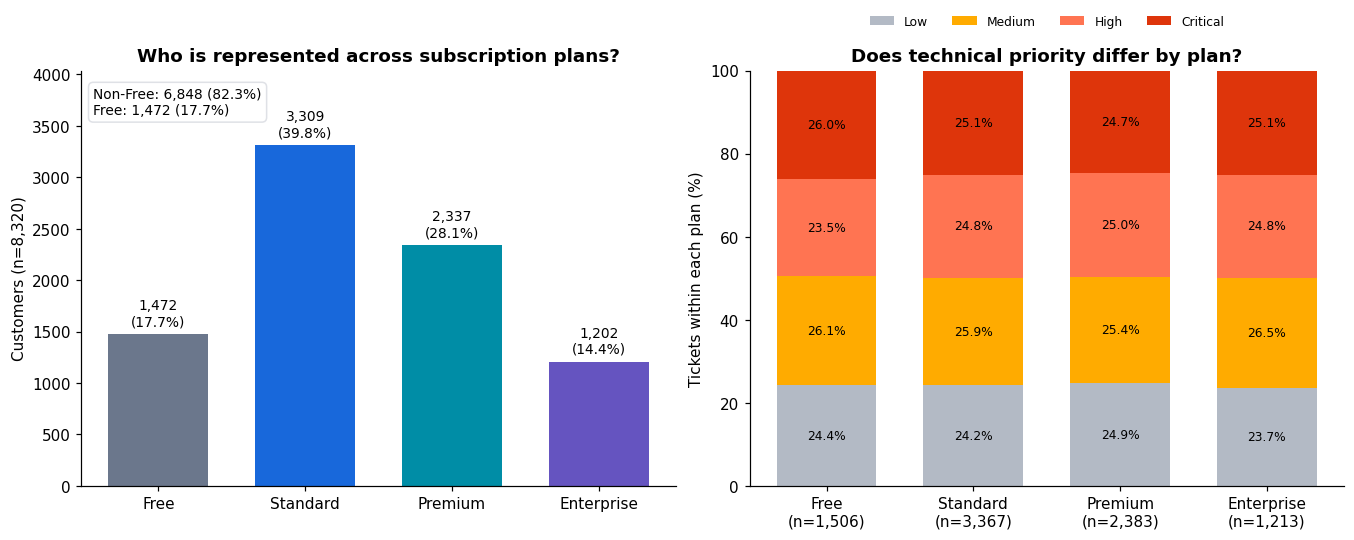

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), layout="constrained")

bars = axes[0].bar(PLAN_ORDER, plan_summary["customers"], color=[PLAN_COLORS[p] for p in PLAN_ORDER], width=.68)
axes[0].bar_label(
    bars,
    labels=[f"{count:,}\n({share:.1%})" for count, share in zip(plan_summary["customers"], plan_summary["share"])],
    padding=4, fontsize=9,
)
axes[0].set(
    title="Who is represented across subscription plans?",
    ylabel=f"Customers (n={len(customers):,})",
    ylim=(0, plan_summary["customers"].max() * 1.22),
)
axes[0].text(
    .02, .96,
    f"Non-Free: {non_free_count:,} ({non_free_count / len(customers):.1%})\n"
    f"Free: {free_count:,} ({free_count / len(customers):.1%})",
    transform=axes[0].transAxes, va="top", fontsize=9,
    bbox={"boxstyle": "round,pad=.35", "facecolor": "white", "edgecolor": LIGHT_GREY},
)

bottom = np.zeros(len(PLAN_ORDER))
for priority in PRIORITY_ORDER:
    values = priority_by_plan_share[priority].to_numpy() * 100
    axes[1].bar(PLAN_ORDER, values, bottom=bottom, color=PRIORITY_COLORS[priority], label=priority, width=.68)
    for index, value in enumerate(values):
        axes[1].text(index, bottom[index] + value / 2, f"{value:.1f}%", ha="center", va="center", fontsize=8)
    bottom += values
axes[1].set(
    title="Does technical priority differ by plan?",
    ylabel="Tickets within each plan (%)", ylim=(0, 100),
    xticks=np.arange(len(PLAN_ORDER)),
    xticklabels=[f"{p}\n(n={priority_by_plan_count.loc[p].sum():,})" for p in PLAN_ORDER],
)
axes[1].legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(.5, 1.16), fontsize=8)
save_show(fig, "01_customer_and_queue_overview.png")

In [5]:
priority_spread = priority_by_plan_share.max(axis=0).sub(priority_by_plan_share.min(axis=0)).max()
display(Markdown(f"""**Observed:** the dataset contains **{len(customers):,} customers**. Non-Free plans account for
**{non_free_count:,}/{len(customers):,} customers ({non_free_count / len(customers):.1%})**; Standard is the largest individual plan.
Within every plan, each technical-priority category represents roughly one quarter of tickets; the largest cross-plan difference for any category is **{priority_spread:.1%}**.

**Business meaning:** commercial plan alone does not visibly create a different technical-priority mix. This motivates checking whether another exposure measure—collaboration reach—is also absent from priority.

**Limitation:** non-Free status is only a plan proxy. The files contain no contract value, realised revenue or SLA entitlement."""))

**Observed:** the dataset contains **8,320 customers**. Non-Free plans account for
**6,848/8,320 customers (82.3%)**; Standard is the largest individual plan.
Within every plan, each technical-priority category represents roughly one quarter of tickets; the largest cross-plan difference for any category is **1.5%**.

**Business meaning:** commercial plan alone does not visibly create a different technical-priority mix. This motivates checking whether another exposure measure—collaboration reach—is also absent from priority.

**Limitation:** non-Free status is only a plan proxy. The files contain no contract value, realised revenue or SLA entitlement.

## 2.3 How Much Satisfaction Evidence Is Actually Available?

Ticket rating is easy to misread because most tickets have no rating. Show
the coverage denominator first, then the distribution of scores only among
tickets that were rated — and check whether ratings appear across every
ticket status, since a rating that's structurally limited to closed
tickets can't be used as if it measured satisfaction for the full queue.

In [6]:
rated_mask = tickets["customer_satisfaction_rating"].notna()
rated_count = int(rated_mask.sum())
unrated_count = int((~rated_mask).sum())
rating_counts = (
    tickets.loc[rated_mask, "customer_satisfaction_rating"]
    .astype(int).value_counts().reindex(range(1, 6), fill_value=0).sort_index()
)
rating_shares = rating_counts / rated_count
rating_status = pd.crosstab(
    tickets["ticket_status"], rated_mask.map({True: "Rated", False: "Not rated"})
)
print(f"{rated_count:,} / {len(tickets):,} tickets are rated ({rated_count/len(tickets):.1%}).")

2,769 / 8,469 tickets are rated (32.7%).


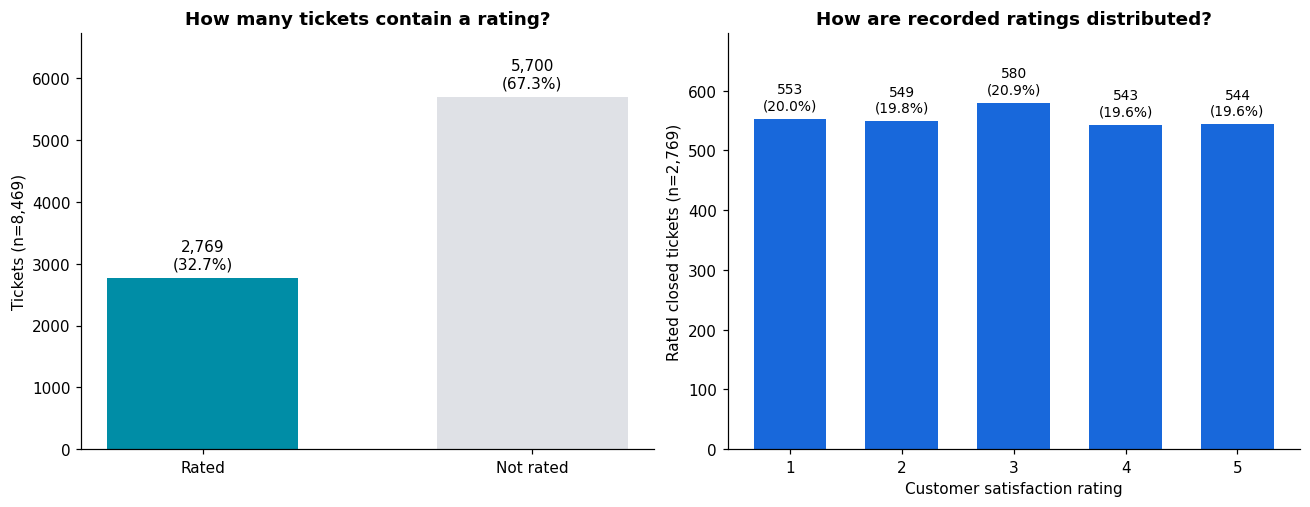

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5), layout="constrained")

coverage_labels = ["Rated", "Not rated"]
coverage_values = [rated_count, unrated_count]
coverage_bars = axes[0].bar(coverage_labels, coverage_values, color=[TEAL, LIGHT_GREY], width=.58)
axes[0].bar_label(
    coverage_bars,
    labels=[f"{value:,}\n({value / len(tickets):.1%})" for value in coverage_values], padding=4,
)
axes[0].set(
    title="How many tickets contain a rating?",
    ylabel=f"Tickets (n={len(tickets):,})", ylim=(0, max(coverage_values) * 1.18),
)

rating_bars = axes[1].bar(rating_counts.index.astype(str), rating_counts.values, color=BLUE, width=.65)
axes[1].bar_label(
    rating_bars,
    labels=[f"{count:,}\n({share:.1%})" for count, share in zip(rating_counts, rating_shares)],
    padding=4, fontsize=9,
)
axes[1].set(
    title="How are recorded ratings distributed?",
    xlabel="Customer satisfaction rating", ylabel=f"Rated closed tickets (n={rated_count:,})",
    ylim=(0, rating_counts.max() * 1.20),
)
save_show(fig, "02_rating_overview.png")

In [8]:
display(Markdown("**Rating availability by ticket status**"))
display(rating_status)

ratings_only_closed = tickets.loc[rated_mask, "ticket_status"].eq("Closed").all()
display(Markdown(f"""**Observed:** only **{rated_count:,}/{len(tickets):,} tickets ({rated_count / len(tickets):.1%})** are rated.
Scores 1–5 are broadly even among those rated tickets, and ratings {'occur only on closed tickets' if ratings_only_closed else 'appear across multiple statuses'}.

**Business meaning:** there is no dominant rating score in the observed closed-ticket feedback, but the rating field describes only a minority of the queue.

**Limitation:** rating missingness is structural, not a value to fill. This notebook therefore does not train a satisfaction model or claim that unrated tickets represent satisfied or dissatisfied customers."""))

**Rating availability by ticket status**

customer_satisfaction_rating,Not rated,Rated
ticket_status,,
Closed,0,2769
Open,2819,0
Pending Customer Response,2881,0


**Observed:** only **2,769/8,469 tickets (32.7%)** are rated.
Scores 1–5 are broadly even among those rated tickets, and ratings occur only on closed tickets.

**Business meaning:** there is no dominant rating score in the observed closed-ticket feedback, but the rating field describes only a minority of the queue.

**Limitation:** rating missingness is structural, not a value to fill. This notebook therefore does not train a satisfaction model or claim that unrated tickets represent satisfied or dissatisfied customers.